# Using Rubin OpSims in Simulations

A critical aspect to producing realistic simulations of time varying phenomena is correctly modeling the cadence at which the objects will be observed and capturing the relevant physical details about the observation. LightCurveLynx provides an `OpSim` module that can load a Rubin opsim file and use that to filter observations based on location, associate observations with their filter, apply detector noise, etc. `OpSim` objects are subclasses of the more general `ObsTable` data structures and a lot of the same concepts apply to `ObsTable`s for different surveys.

**NOTE:** This notebook provides an introduction to using opsim data in the simulations. Actual observations from LSSTCam are provided in a different format and should be loaded using the `LSSTObsTable` class. For an example of how to load a CCD Visit table from actual runs, such as DP1, see the [corresponding notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/rubin_ccdvisit.html).

## OpSim Class

The `OpSim` object provides a wrapper for loading and querying simulated Rubin survey data, including pointings and survey information. The required information is:
  * the pointing data (RA, dec, and times for each pointing), and
  * the zero point information for each pointing (a zero point column or the information needed to derive it)

Other common information includes the airmass, exposure time, and filter used (the information needed to derive the zero points).

Internally, the `OpSim` objects use a table with the column names are given by the imported data. For Rubin opsim files, this means columns will have names such as "observationStartMJD" or "fieldRA". Since different inputs may have different columns, the class provides the ability to map simple column names such as "ra" and "time" to the corresponding table names. The constructor allows the user to pass a column-mapping dictionary that maps the short column name to the name used within the database. The default column-mapper corresponds to the Rubin opsim format:
  * "airmass" -> "airmass"
  * "dec" -> "fieldDec"
  * "exptime" -> "visitExposureTime"
  * "filter" -> "filter"
  * "ra" -> "fieldRA"
  * "time" -> "observationStartMJD"
By default `OpSim` will look for Rubin column names, such as "observationStartMJD" and "fieldRA".

We can create a simple `OpSim` by manually specifying the data as a dict or a pandas dataframe.

In [1]:
import numpy as np

from lightcurvelynx.obstable.opsim import OpSim

input_data = {
    "observationStartMJD": np.array([0.0, 1.0, 2.0, 3.0, 4.0]),
    "fieldRA": np.array([15.0, 30.0, 15.0, 0.0, 60.0]),
    "fieldDec": np.array([-10.0, -5.0, 0.0, 5.0, 10.0]),
    "zp_nJy": np.ones(5),
}
ops_data = OpSim(input_data)
print(ops_data._table)

   time    ra   dec   zp
0   0.0  15.0 -10.0  1.0
1   1.0  30.0  -5.0  1.0
2   2.0  15.0   0.0  1.0
3   3.0   0.0   5.0  1.0
4   4.0  60.0  10.0  1.0


Once we have an `OpSim` object, we can use the `[]` notation to access data directly. `OpSim` has the same mechanics as a pandas data frame. The columns are named and correspond to input attributes. Each row provides the information for a single pointing.

As noted above, the column mapping allows us to access column by either their given name ("observationStartMJD") or their shortened name ("time").

In [2]:
ops_data["observationStartMJD"]  # Same as ops_data["time"]

0    0.0
1    1.0
2    2.0
3    3.0
4    4.0
Name: time, dtype: float64

## Loading an OpSim

Most users will want to load a pre-existing `OpSim` from a database file using the `from_db()`, `from_url()`, or `from_parquet()` functions.  The `from_url()` function will download the opsim db from a given URL to LightCurveLynx's data cache (if needed) and load the opsim from the db file.  For Rubin, a large number of OpSims can be found at [https://s3df.slac.stanford.edu/data/rubin/sim-data/](https://s3df.slac.stanford.edu/data/rubin/sim-data/). For many studies you will want the most recent version of a baseline survey. But some users might want older versions or alternate approaches.

In [3]:
opsim_url = "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs5.3/baseline/baseline_v5.3.0_10yrs.db"

# Uncomment the following line to load data from a URL
# ops_data = OpSim.from_url(opsim_url)

If the file has already been downloaded, the code will not redownload it unless the user sets `force_download=True`.

Alternatively if you are using a local OpSim with a known file path, you can use `from_db()` or `from_parquet()` to read it directly.

In [4]:
opsim_file = "../../tests/lightcurvelynx/data/opsim_shorten.db"
ops_data = OpSim.from_db(opsim_file)

print(f"Loaded an opsim database with {len(ops_data)} entries.")
print(f"Columns: {ops_data.columns}")

Loaded an opsim database with 100 entries.
Columns: Index(['observationId', 'ra', 'dec', 'time', 'flush_by_mjd', 'exptime', 'band',
       'filter', 'rotation', 'rotSkyPos_desired', 'nexposure', 'airmass',
       'seeingFwhm500', 'seeing', 'seeingFwhmGeom', 'skybrightness', 'night',
       'slewTime', 'visitTime', 'slewDistance', 'maglim', 'altitude',
       'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt',
       'scheduler_note', 'target_name', 'target_id', 'observationStartLST',
       'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec',
       'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase',
       'cummTelAz', 'observation_reason', 'science_program',
       'cloud_extinction', 'zp', 'psf_footprint', 'sky_bg_e'],
      dtype='object')


We can create a Multi-Order Coverage Map (MOC) of the area covered by the `OpSim` (or any `ObsTable`)

In [5]:
moc = ops_data.build_moc()

We can also plot the survey's coverage on the sky.

(<Figure size 640x480 with 1 Axes>, <WCSAxes: >)

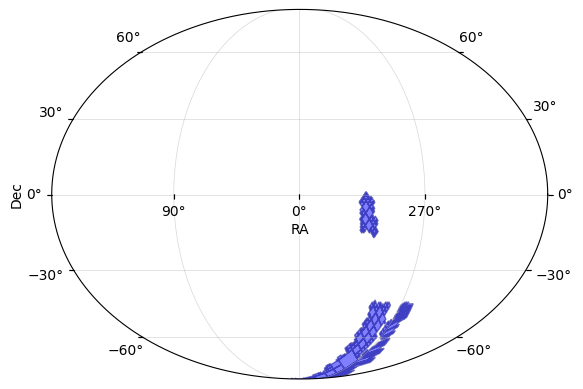

In [6]:
ops_data.plot_footprint()

## Spatial Matching

`OpSim` provides a framework for efficiently determining when an object was observed given its (RA, Dec). We use the `range_search()` function to retrieve all pointings within a given radius of the query point.

We start by taking the (RA, Dec) of the first observation in the table and using that to determine all times this position was observed.

In [7]:
query_ra = ops_data["ra"][0]
query_dec = ops_data["dec"][0]
print(f"Searching for ({query_ra}, {query_dec}).")

# Find everything within 0.5 degrees of the query point.
matches = ops_data.range_search(query_ra, query_dec, radius=0.5)
print(f"Found {len(matches)} matches at {matches}")

Searching for (266.3779106872175, -45.89452409985622).
Found 1 matches at [0]


/Users/hombit/projects/lincc-frameworks/lightcurvelynx/src/lightcurvelynx/obstable/obs_table.py:792: UserWarning: Provided radius 0.5 is smaller than the ObsTable radius 1.75. This may lead to unexpected results if a detector footprint is used.
  warnings.warn(


Once we have the indices, we can use those to find the other information about the pointings.

In [8]:
ops_data["time"][matches]

0    61208.201382
Name: time, dtype: float64

We can run the spatial search in batch mode by providing a lists of RA and Dec. The `range_search()` will return a list of numpy arrays where each element in the top-level list represents the matches for a single query (RA, Dec). 

In [9]:
num_queries = 10
query_ra = ops_data["ra"][0:num_queries]
query_dec = ops_data["dec"][0:num_queries]

matches = ops_data.range_search(query_ra, query_dec, radius=0.5)
for idx, m_ids in enumerate(matches):
    print(f"{idx}: ({query_ra[idx]}, {query_dec[idx]}) matched {m_ids}")

0: (266.3779106872175, -45.89452409985622) matched [0]
1: (262.5748648414665, -46.941452495343185) matched [1]
2: (266.0393615420718, -49.016650863930515) matched [2]
3: (261.992377462464, -50.03784354356154) matched [3]
4: (265.67981873765643, -52.13207689104739) matched [4]
5: (269.72204970823844, -54.10114091549846) matched [5]
6: (265.2667462932809, -55.244470135924985) matched [6]
7: (269.6256661659721, -57.21212976851723) matched [7]
8: (264.77758769880876, -58.353310675122174) matched [8]
9: (261.839995058087, -63.40602538449797) matched [9]


/Users/hombit/projects/lincc-frameworks/lightcurvelynx/src/lightcurvelynx/obstable/obs_table.py:792: UserWarning: Provided radius 0.5 is smaller than the ObsTable radius 1.75. This may lead to unexpected results if a detector footprint is used.
  warnings.warn(


## Applying Noise

Users can apply different noise models that use information from the `OpSim`. By default the ``OpSim`` will use a ``PoissonFluxNoiseModel``. These noise models take the predicted fluxes for a subset of observations (bandflux of the point source in nJy), the `ObsTable`, and the corresponding row indices of those observations (in the `ObsTable`). It returns the simulated bandflux noise in nJy and the modified observations.


In [10]:
from lightcurvelynx.noise_models.base_noise_models import PoissonFluxNoiseModel

fluxes = np.array([100.0, 200.0, 300.0])

noise_model = PoissonFluxNoiseModel()
noisy_fluxes, flux_errors = noise_model.apply_noise(
    fluxes,
    obs_table=ops_data,
    indices=np.array([0, 1, 2]),
    rng=np.random.default_rng(42),
)
print("Noisy fluxes:", noisy_fluxes)
print("Flux errors:", flux_errors)

Noisy fluxes: [154.93700274  10.4728971  438.50155313]
Flux errors: [180.28855747 182.24038403 184.55770862]


## Filtering

Depending on the analysis we run, we might want to use only a subset of the data.  `OpSim` provides a helper function `filter_rows()` that can be used to filter the data in an `OpSim` and thus speed up subsequent operations. This function creates a new copy of the data set with a subset of the rows.

In [11]:
input_data["filter"] = np.array(["r", "g", "g", "r", "g"])
ops_data2 = OpSim(input_data)

print("BEFORE:")
print(ops_data2._table)

ops_data3 = ops_data2.filter_rows(ops_data2["filter"] == "g")

print("\n\nAFTER:")
print(ops_data3._table)

BEFORE:
   time    ra   dec   zp filter
0   0.0  15.0 -10.0  1.0      r
1   1.0  30.0  -5.0  1.0      g
2   2.0  15.0   0.0  1.0      g
3   3.0   0.0   5.0  1.0      r
4   4.0  60.0  10.0  1.0      g


AFTER:
   time    ra   dec   zp filter
0   1.0  30.0  -5.0  1.0      g
1   2.0  15.0   0.0  1.0      g
2   4.0  60.0  10.0  1.0      g


In addition to filtering the rows in the table, the function will also update the cached data structures within the `OpSim` object, such as the KD-tree.

## Scalability and Testing

To test the scalability of the OpSim we can user the `create_random_opsim()` helper function to generate completely random data by sampling uniformly over the surface of a sphere. This will not be a realistic survey since it will cover both the Northern and Southern hemisphere, but can provide a good test set for timing.

In [12]:
from lightcurvelynx.obstable.opsim import create_random_opsim

# Create an opsim with 1,000,000 observations.
num_obs = 1_000_000
opsim_data2 = create_random_opsim(num_obs)

# Use the first 10,000 samples as queries.
num_queries = 100_000
query_ra = np.asarray(opsim_data2["ra"][0:num_queries])
query_dec = np.asarray(opsim_data2["dec"][0:num_queries])

Using the large OpSim data, we can test where batching speeds up the range search.

In [13]:
%%timeit
for i in range(num_queries):
    _ = opsim_data2.range_search(query_ra[i], query_dec[i], radius=0.5)

/Users/hombit/projects/lincc-frameworks/lightcurvelynx/src/lightcurvelynx/obstable/obs_table.py:792: UserWarning: Provided radius 0.5 is smaller than the ObsTable radius 1.75. This may lead to unexpected results if a detector footprint is used.
  warnings.warn(


2.06 s ± 51.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [14]:
%%timeit
_ = opsim_data2.range_search(query_ra, query_dec, radius=0.5)

350 ms ± 11.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Sampling

We can sample RA, Dec, and time from an `OpSim` object using the `ObsTableRADECSampler` node. This will select a random observation from the OpSim and then create a random (RA, Dec) from near the center of that observation.

This allows us to generate fake query locations for testing that are compatible with arbitrary OpSims as opposed to generating a large number of fake locations and then filtering only those that match the opsim. The distribution will be weighted by the opsim's pointing. If it points at region A 90% of time time and region B 10% of the time, then 90% of the resulting points will be from region A and 10% from region B.

In [15]:
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler

sampler_node = ObsTableRADECSampler(ops_data)

# Test we can generate a single value.
(ra, dec, time) = sampler_node.generate(num_samples=10)

for i in range(10):
    print(f"{i}: ({ra[i]}, {dec[i]}) at t={time[i]}")

0: (299.6778207785411, -75.23964821212081) at t=61208.28960502226
1: (313.3814009993918, -12.442516550696237) at t=61208.31133826603
2: (280.4573920554708, -52.61638376769602) at t=61208.27394261975
3: (269.0311430217272, -53.78073652730608) at t=61208.20410552483
4: (286.91336848815956, -66.31400184045846) at t=61208.291150320736
5: (287.8679354862556, -74.16653764154738) at t=61208.264942839116
6: (290.76598477420686, -79.31885458485385) at t=61208.288572955615
7: (295.8057639653965, -59.47560123727411) at t=61208.26755574232
8: (294.95149149806343, -71.62462337683476) at t=61208.29012043673
9: (313.6796132815519, -9.138433470983124) at t=61208.31185683879
